Outputs `spots_raw.h5ad` as intermediate data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from mcDETECT.model import *

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

In [2]:
# Settings
settings = {
    # "MERSCOPE_2m_WT_R1": {"pixel_size": 0.10799861, "x_shift": int(-266.1734), "y_shift": int(180.2510), "cutoff": 6250, "theta": 10 * np.pi / 180, "coordinate_for_rotation": ["global_y", "global_x"], "coordinate_for_cutoff": "global_y", "cutoff_direction": "smaller"},
    # "MERSCOPE_2m_AD_R1": {"pixel_size": 0.10799905, "x_shift": int(-126.9911), "y_shift": int(-20.3805), "cutoff": -4200, "theta": 170 * np.pi / 180, "coordinate_for_rotation": ["global_x", "global_y"], "coordinate_for_cutoff": "global_x", "cutoff_direction": "larger"},
    "MERSCOPE_9m_AD_R1": {"pixel_size": 0.1079991995, "x_shift": int(-17.2801), "y_shift": int(277.6227), "cutoff": -6000, "theta": 200 * np.pi / 180, "coordinate_for_rotation": ["global_x", "global_y"], "coordinate_for_cutoff": "global_x", "cutoff_direction": "smaller"},
    "MERSCOPE_9m_AD_R2": {"pixel_size": 0.10799904, "x_shift": int(-31.3303), "y_shift": int(268.1251), "cutoff": -5850, "theta": 190 * np.pi / 180, "coordinate_for_rotation": ["global_x", "global_y"], "coordinate_for_cutoff": "global_x", "cutoff_direction": "larger"},
    "MERSCOPE_9m_WT_R1": {"pixel_size": 0.10799939, "x_shift": int(-53.0503), "y_shift": int(29.6203), "cutoff": -5450, "theta": 185 * np.pi / 180, "coordinate_for_rotation": ["global_x", "global_y"], "coordinate_for_cutoff": "global_x", "cutoff_direction": "smaller"},
    "MERSCOPE_9m_WT_R2": {"pixel_size": 0.10799863, "x_shift": int(145.7568), "y_shift": int(-127.0323), "cutoff": -5850, "theta": 190 * np.pi / 180, "coordinate_for_rotation": ["global_x", "global_y"], "coordinate_for_cutoff": "global_x", "cutoff_direction": "larger"},
    }

Processing MERSCOPE_9m_AD_R1...
AnnData object with n_obs × n_vars = 14399 × 290
    obs: 'spot_id', 'global_x', 'global_y'
    var: 'genes'


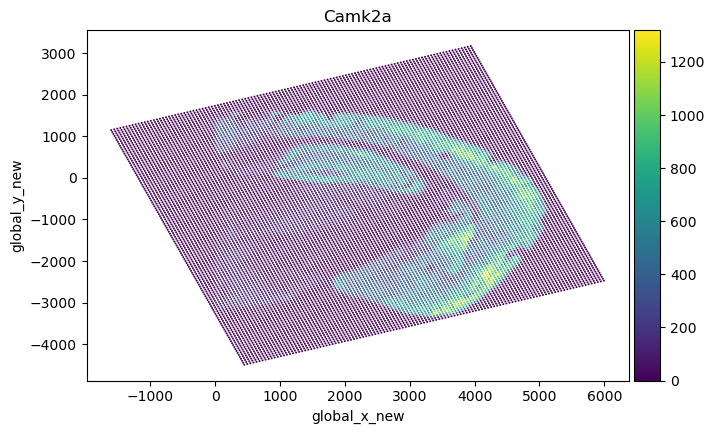

Processing MERSCOPE_9m_AD_R2...
AnnData object with n_obs × n_vars = 14750 × 290
    obs: 'spot_id', 'global_x', 'global_y'
    var: 'genes'


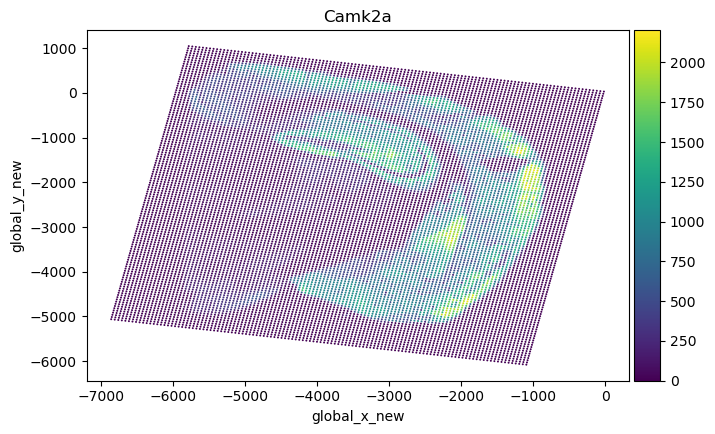

Processing MERSCOPE_9m_WT_R1...
AnnData object with n_obs × n_vars = 14763 × 290
    obs: 'spot_id', 'global_x', 'global_y'
    var: 'genes'


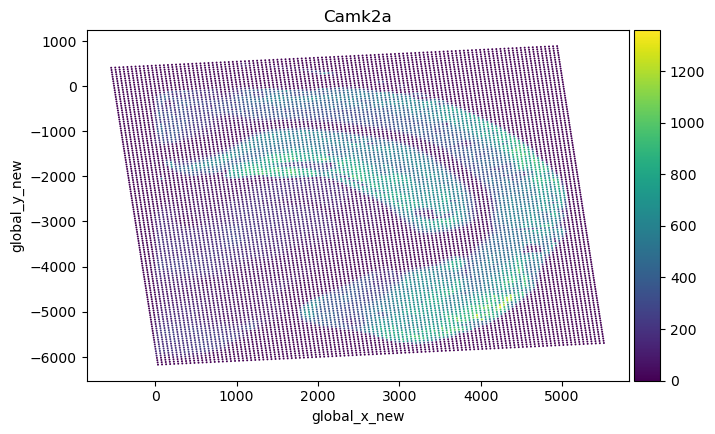

Processing MERSCOPE_9m_WT_R2...
AnnData object with n_obs × n_vars = 12862 × 290
    obs: 'spot_id', 'global_x', 'global_y'
    var: 'genes'


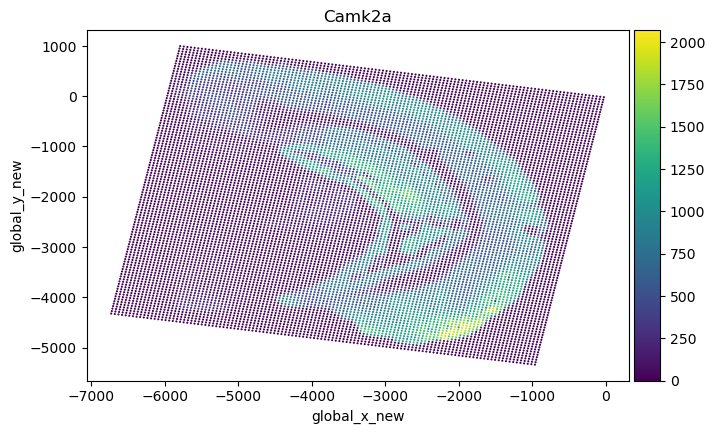

In [5]:
# Main operations

for dataset in settings.keys():
    
    print("=" * 25)
    print(f"Processing {dataset}...")
    print("=" * 25)
    
    # File paths
    data_path = f"../data/{dataset}/"
    output_path = f"../output/{dataset}/"
    
    # Read data
    transcripts = pd.read_parquet(data_path + "processed_data/transcripts.parquet")
    genes = pd.read_csv(data_path + "processed_data/genes.csv")
    genes = genes["genes"].tolist()
    
    # Initialize mcDETECT
    mc = mcDETECT(type = "continuous", transcripts = transcripts, gnl_genes = None, nc_genes = None)
    
    # Construct spots
    spots = mc.spot_expression(grid_len = 50, genes = genes)
    print(spots)
    
    # Rotate spots
    cutoff = settings[dataset]["cutoff"]
    theta = settings[dataset]["theta"]
    coordinate_for_rotation = settings[dataset]["coordinate_for_rotation"]
    coordinate_for_cutoff = settings[dataset]["coordinate_for_cutoff"]
    cutoff_direction = settings[dataset]["cutoff_direction"]
    
    rotation_matrix = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    coords = spots.obs[coordinate_for_rotation].to_numpy()
    transformed_coords = coords @ rotation_matrix.T
    spots.obs[f"{coordinate_for_rotation[0]}_new"] = transformed_coords[:, 0]
    spots.obs[f"{coordinate_for_rotation[1]}_new"] = transformed_coords[:, 1]
    
    if cutoff_direction == "smaller":
        spots.obs[f"{coordinate_for_cutoff}_new"] = cutoff - spots.obs[f"{coordinate_for_cutoff}_new"]
    
    ax = sc.pl.scatter(spots, x = f"{coordinate_for_rotation[0]}_new", y = f"{coordinate_for_rotation[1]}_new", color = "Camk2a", show = False)
    plt.show()
    
    spots.write_h5ad(data_path + "intermediate_data/spots_raw.h5ad")